## __Unsupervised Learning - K-Means Clustering__
K-Means clustering is a type of unsupervised learning algorithms. In unsupervised learning, the machine learning model do not get the labels during training. It instead has to figure out the labels itself. It's like learning without instructions. It's like a teacher telling you, "hey, here are 1000 exercises to use while preparing for a test, the test will be only 5 questions from all of those exercises." That can feel like a struggle, you will do all you can to narrow down these 100 exercises to 5. Some questions may be similar, or may be solved by one method, etc..the goal will merely be to narrow down the exercises, while maximizing the chance of passing the test.

That type of example can be compared to clustering. The model is given bunch of data (lacking labels) and the job of the model is to find the labels that can be present according to the supplied data.

K-Means Clustering require the number of clusters to be specified before training. The way this type of algorithm works is beyond the scope of this notebook but here are 3 main steps of how such algorithm work:

K-Means will randomly assigns samples of data to initial centroids of all clusters. This step is called initialization. A centroid is also referred to as a cluster center and it is the mean of all the sample of data in a cluster.

It then reassigns the samples to the nearest centroids.

It also find the new centroids of all clusters by taking the mean value of all of the samples assigned to each previous centroids.

The last two steps are repeated until the stopping criterion is fulfilled or when difference between the old and new centroids is constant.

Unspervised learning has got its applications in areas such as grouping web search results, customer segmentation, news aggregation and more.

### KMeans Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
%matplotlib inline

### Loading the dataset
In this notebook, we will use a mushroom dataset. The dataset describes mushrooms in terms of their physical characteristics and they are classified into: poisonous or edible.

The dataset also includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family. Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the poisonous one. The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like `leaflets three, let it be for Poisonous Oak and Ivy`.

The dataset contains the labels (edibility) but for the purpose of doing clustering, we will remove the labels.

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

In [3]:
from sklearn.datasets import fetch_openml

mushroom_data=fetch_openml(name='mushroom',version=1)

In [4]:
mushroom_data.data.shape

(8124, 22)

In [6]:
mushroom_data.details

{'id': '24',
 'name': 'mushroom',
 'version': '1',
 'description_version': '1',
 'format': 'ARFF',
 'creator': 'Jeff Schlimmer',
 'collection_date': '1987-04-27',
 'upload_date': '2014-04-06T23:21:11',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://api.openml.org/data/v1/download/24/mushroom.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0024/dataset_24.pq',
 'file_id': '24',
 'default_target_attribute': 'class',
 'version_label': '1',
 'citation': 'The Audubon Society Field Guide to North American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred A. Knopf',
 'tag': ['Botany',
  'Ecology',
  'Kaggle',
  'mythbusting_1',
  'OpenML100',
  'study_1',
  'study_123',
  'study_14',
  'study_144',
  'study_15',
  'study_190',
  'study_20',
  'study_34',
  'study_37',
  'study_41',
  'study_50',
  'study_70',
  'trivial',
  'uci'],
 'visibility': 'public',
 'original_data_url': 'https://archive.ics.uci.edu/ml/datasets/mushroom',
 'paper_url': 'https://esc

In [8]:
print(mushroom_data.DESCR)

**Author**: [Jeff Schlimmer](Jeffrey.Schlimmer@a.gp.cs.cmu.edu)  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/mushroom) - 1981     
**Please cite**:  The Audubon Society Field Guide to North American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred A. Knopf 


### Description

This dataset describes mushrooms in terms of their physical characteristics. They are classified into: poisonous or edible.

### Source
```
(a) Origin: 
Mushroom records are drawn from The Audubon Society Field Guide to North American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred A. Knopf 

(b) Donor: 
Jeff Schlimmer (Jeffrey.Schlimmer '@' a.gp.cs.cmu.edu)
```

### Dataset description

This dataset includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family. Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended. This latter class was combined with the

In [12]:
mushroom_data.frame

,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,o,o,p,o,o,p,b,c,l,e
8120,x,s,n,f,n,a,c,b,y,e,...,o,o,p,n,o,p,b,v,l,e
8121,f,s,n,f,n,a,c,b,n,e,...,o,o,p,o,o,p,b,c,l,e
8122,k,y,n,f,y,f,c,n,b,t,...,w,w,p,w,o,e,w,v,l,p


In [13]:
mushroom_data.feature_names , mushroom_data.target_names

(['cap-shape',
  'cap-surface',
  'cap-color',
  'bruises%3F',
  'odor',
  'gill-attachment',
  'gill-spacing',
  'gill-size',
  'gill-color',
  'stalk-shape',
  'stalk-root',
  'stalk-surface-above-ring',
  'stalk-surface-below-ring',
  'stalk-color-above-ring',
  'stalk-color-below-ring',
  'veil-type',
  'veil-color',
  'ring-number',
  'ring-type',
  'spore-print-color',
  'population',
  'habitat'],
 ['class'])

### __EDA__

In [14]:
mushroom_data=mushroom_data.frame
mushroom_data.head(5)

,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [16]:
mushroom_data.describe().transpose()

,count,unique,top,freq
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises%3F,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728
stalk-shape,8124,2,t,4608


In [17]:
mushroom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   cap-shape                 8124 non-null   category
 1   cap-surface               8124 non-null   category
 2   cap-color                 8124 non-null   category
 3   bruises%3F                8124 non-null   category
 4   odor                      8124 non-null   category
 5   gill-attachment           8124 non-null   category
 6   gill-spacing              8124 non-null   category
 7   gill-size                 8124 non-null   category
 8   gill-color                8124 non-null   category
 9   stalk-shape               8124 non-null   category
 10  stalk-root                5644 non-null   category
 11  stalk-surface-above-ring  8124 non-null   category
 12  stalk-surface-below-ring  8124 non-null   category
 13  stalk-color-above-ring    8124 non-null   catego

In [18]:
mushroom_data.isnull().sum()

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises%3F                     0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

It seems that we have missing values in the feature `stalk-root`.

Usually there are three things to do with if them if they are present:

We can remove all missing values completely
We can leave them as they are or
We can fill them with a given strategy such as mean, media or most frequent value. Either `Sklearn` or `Pandas` provides a quick ways to fill these kind of values.
We will handle that during the data preprocessing.

<Axes: xlabel='cap-shape', ylabel='count'>

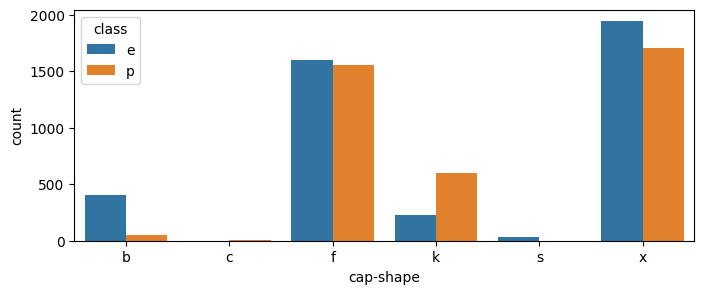

In [19]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='cap-shape',hue='class')

In `cap-shape` the letters stands for, `bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s`. It seems that the convex type is dominant and most of it are edible.

<Axes: xlabel='cap-color', ylabel='count'>

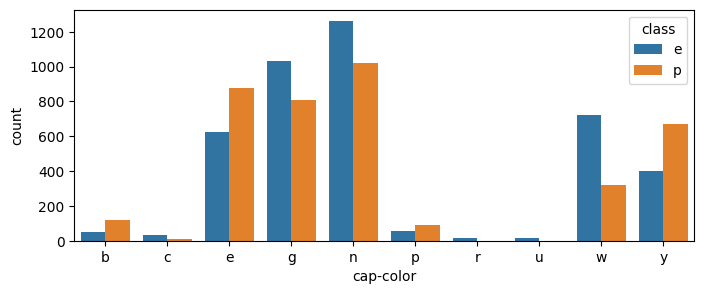

In [21]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='cap-color', hue='class')

The above `cap-color` alphabets stands for, `brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y`.\
Also it seems that most caps are brown(n), either edible or brown.

<Axes: xlabel='population', ylabel='count'>

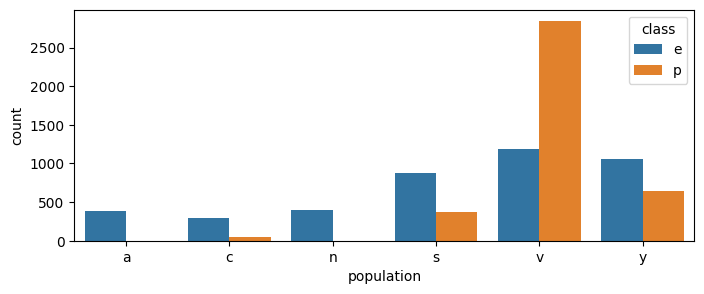

In [22]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='population',hue='class')

The most populations are most several. Here are what the letters stand for: `abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y`.

<Axes: xlabel='habitat', ylabel='count'>

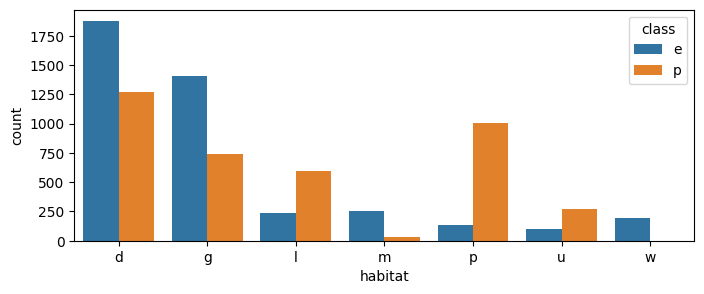

In [23]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='habitat',hue='class')

Here, Habitat alphabets stand for - `grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d`. Woods is the mushroom rich habitat especially for edible class

<Axes: xlabel='stalk-root', ylabel='count'>

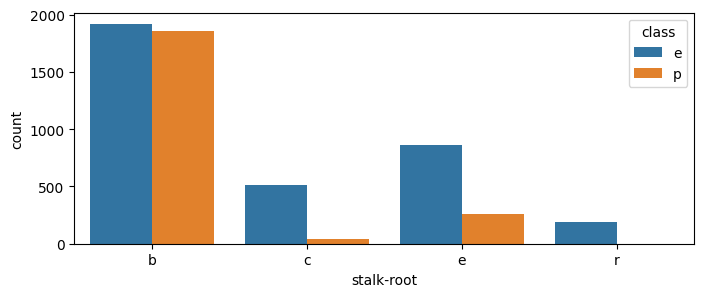

In [26]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='stalk-root',hue='class')

Here, `stalk-root` alphabets stands for - `bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?`

In [38]:
mushroom_data['stalk-root'].value_counts()

stalk-root
b    3776
e    1120
c     556
r     192
Name: count, dtype: int64

Above is the feature that is missing values. We will remove all missing values. Since the missing values are of one category, we will drop it to avoid adding noise in the dataset.

And finally, we can look in the class feature. There are two categories, `e(edible)` and `p(poisonous)`.

<Axes: xlabel='class', ylabel='count'>

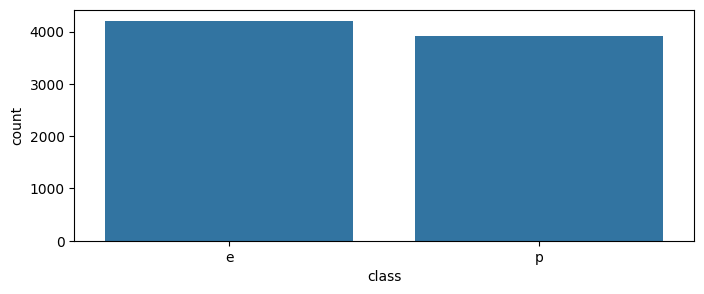

In [39]:
plt.figure(figsize=(8,3))
sns.countplot(data=mushroom_data,x='class')

### __Data Preprocessing__

In [40]:
mushroom_df=mushroom_data.dropna()

* For the purpose of performing clustering, we will remove the labels.

In [41]:
mushroom=mushroom_df.drop('class',axis=1)
mushroom_label=mushroom_df['class']

In [42]:
from sklearn.preprocessing import OrdinalEncoder

encoder=OrdinalEncoder()

mushroom_prepared=encoder.fit_transform(mushroom)

In [43]:
mushroom_prepared

array([[5., 2., 4., ..., 1., 3., 5.],
       [5., 2., 7., ..., 2., 2., 1.],
       [0., 2., 6., ..., 2., 2., 3.],
       ...,
       [5., 3., 3., ..., 5., 5., 4.],
       [5., 3., 1., ..., 5., 1., 0.],
       [2., 3., 1., ..., 5., 1., 0.]], shape=(5644, 22))

As you can see above, `mushroom_prepared` is a NumPy array. We can convert it back to the Pandas Dataframe although KMeans algorithm can accept both as input.

In [44]:
mushroom_prep_df=pd.DataFrame(mushroom_prepared,columns=mushroom.columns)

In [45]:
mushroom_prep_df.head(5)

,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5.0,2.0,4.0,1.0,6.0,1.0,0.0,1.0,2.0,0.0,...,2.0,5.0,5.0,0.0,0.0,1.0,3.0,1.0,3.0,5.0
1,5.0,2.0,7.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,...,2.0,5.0,5.0,0.0,0.0,1.0,3.0,2.0,2.0,1.0
2,0.0,2.0,6.0,1.0,3.0,1.0,0.0,0.0,3.0,0.0,...,2.0,5.0,5.0,0.0,0.0,1.0,3.0,2.0,2.0,3.0
3,5.0,3.0,6.0,1.0,6.0,1.0,0.0,1.0,3.0,0.0,...,2.0,5.0,5.0,0.0,0.0,1.0,3.0,1.0,3.0,5.0
4,5.0,2.0,3.0,0.0,5.0,1.0,1.0,0.0,2.0,1.0,...,2.0,5.0,5.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0


No alphabets anymore. They were perfectly encoded or converted to numerics representation.

We are now ready to find the labels with KMeans Clustering. Again, this is for the assumption that we do not have labels, or to make it simple, we have a data about the characteristics of different plants, but we do not know if they are edible or not. We want to use unsupervised learning to figure that out.

### __Training K-Means Clustering to Find Clusters__

We are going to create a KMeans model from sklearn.cluster. We will remember to provide the number of the clusters, which is 2 in our case.

In [46]:
from sklearn.cluster import KMeans

k_cluster=KMeans(n_clusters=2,random_state=42)
k_cluster.fit(mushroom_prep_df)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [49]:
k_cluster.cluster_centers_

array([[ 3.44593056e+00,  1.57797382e+00,  3.67558338e+00,
         7.25099602e-01,  4.56431417e+00,  9.94877632e-01,
         2.48150256e-01,  1.53101878e-01,  4.62692089e+00,
         7.52988048e-01,  7.34490609e-01,  1.74473534e+00,
         1.79681275e+00,  4.29624360e+00,  4.26892430e+00,
         0.00000000e+00,  2.27660785e-03,  1.01935117e+00,
         2.34120660e+00,  1.63972681e+00,  3.58252703e+00,
         9.05805350e-01],
       [ 3.37793427e+00,  1.70845070e+00,  5.25821596e+00,
         2.98591549e-01,  1.91596244e+00,  1.00000000e+00,
         7.13615023e-02,  7.79342723e-02,  1.73849765e+00,
         1.09859155e-01,  3.71361502e-01,  1.28873239e+00,
         1.32676056e+00,  3.37793427e+00,  3.37793427e+00,
         0.00000000e+00, -4.03323208e-17,  1.00751174e+00,
         1.69248826e+00,  5.15492958e-01,  3.92816901e+00,
         1.78075117e+00]])

Also, we can get the labels that the KMeans provided for each data point.

In [53]:
k_labels=k_cluster.labels_
k_labels

array([0, 1, 1, ..., 0, 0, 0], shape=(5644,), dtype=int32)

### __Evaluating K-Means Clustering__
In real world, evaluating the performance of KMeans is not an easy thing, because there are not true labels to compare with the clustered labels. In our case since we have them, we can find things like accuracy score, or even find the confusion matrix to display the actual and predicted classes. Not to mention classification report to find things like Recall, Precision, or F1 Score.

But again since we are merely comparing the labels(true and clustered), we do not need that extra metrics.

Before finding the accuracy score, I will first convert the true labels into the numbers or encode them. For simplicity, I will use a map function.

In [54]:
map_dict={
    'p':0,
    'e':1
}
mushroom_label_prep=mushroom_label.map(map_dict)

In [55]:
mushroom_label_prep

0       0
1       1
2       1
3       0
4       1
       ..
7986    1
8001    1
8038    1
8095    0
8114    0
Name: class, Length: 5644, dtype: category
Categories (2, int64): [1, 0]

In [57]:
from sklearn.metrics import accuracy_score

accuracy_score(mushroom_label_prep,k_labels)

0.2074769666902906

This is not excellent, but it's so impressive. Why? Well, KMeans never saw the labels, it was only feed the data of different characteristics of poisonous and edible mushrooms and its job was to try to find patterns in the data so as to learn if a given mushroom specy is a poisonous or edible.

KMeans algorithm is very useful in areas where you have a bunch of unlabeled data. Take an example in customer segmentation. You may want to provide different promotions to some groups of your customers but you have no clue of who would benefit from that particular promotion. So, you can try to find the group of customers using this algorithm. It will try to group similar customers according to their interests, and will likely appreciate the promotion.